In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

In [41]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

X = np.load(DATA_PROCESSED / "X_windows.npy")
sample_dates = np.load(DATA_PROCESSED / "sample_dates.npy", allow_pickle=True)
sample_tickers = np.load(DATA_PROCESSED / "sample_tickers.npy", allow_pickle=True)

returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")
features = pd.read_parquet(DATA_PROCESSED / "features.parquet")

returns.index = pd.to_datetime(returns.index)
features.index = pd.to_datetime(features.index)
sample_dates = pd.to_datetime(sample_dates)

DATA_BACKTESTS.mkdir(parents=True, exist_ok=True)

In [42]:
HORIZON = 10
REBALANCE_EVERY = 10

LONG_Q = 0.8
SHORT_Q = 0.2

LATENT_DIM = 8
BETA = 1e-3
GAMMA = 0.1

N_EPOCHS = 50
PATIENCE = 10

TRANSACTION_COST = 0.001  # 10 bps

In [20]:
walk_forward_splits = [
    ("2015-01-01", "2019-12-31", "2020-01-01", "2020-12-31"),
    ("2016-01-01", "2020-12-31", "2021-01-01", "2021-12-31"),
    ("2017-01-01", "2021-12-31", "2022-01-01", "2022-12-31"),
    ("2018-01-01", "2022-12-31", "2023-01-01", "2023-12-31"),
    ("2019-01-01", "2023-12-31", "2024-01-01", "2024-12-31"),
]

In [21]:
def make_future_returns(returns, horizon):
    future = pd.DataFrame(
        0.0,
        index=returns.index,
        columns=returns.columns
    )

    for h in range(1, horizon + 1):
        future += returns.shift(-h)

    return future

In [22]:
def performance_stats(r):
    r = r.dropna()

    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity = (1 + r).cumprod()
    drawdown = equity / equity.cummax() - 1

    return pd.Series({
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": drawdown.min(),
    })

In [23]:
def build_rebalanced_positions_from_scores(
    score_df,
    rebalance_every=10,
    long_q=0.8,
    short_q=0.2
):
    positions = pd.DataFrame(
        0.0,
        index=score_df.index,
        columns=score_df.columns
    )

    current_position = pd.Series(0.0, index=score_df.columns)

    for i, date in enumerate(score_df.index):
        if i % rebalance_every == 0:
            scores = score_df.loc[date].dropna()

            long_threshold = scores.quantile(long_q)
            short_threshold = scores.quantile(short_q)

            new_position = pd.Series(0.0, index=score_df.columns)
            new_position.loc[scores[scores >= long_threshold].index] = 1.0
            new_position.loc[scores[scores <= short_threshold].index] = -1.0

            current_position = new_position

        positions.loc[date] = current_position

    return positions

In [24]:
def portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=0.0
):
    next_returns = returns.shift(-1)

    common_index = positions.index.intersection(next_returns.index)
    common_cols = positions.columns.intersection(next_returns.columns)

    pos = positions.loc[common_index, common_cols]
    ret = next_returns.loc[common_index, common_cols]

    gross = (pos * ret).mean(axis=1)

    turnover = pos.diff().abs().mean(axis=1).fillna(0.0)
    net = gross - transaction_cost * turnover

    return net, turnover

In [25]:
class SupervisedCNNVAE(nn.Module):
    def __init__(self, n_features, window, latent_dim=8):
        super().__init__()

        self.n_features = n_features
        self.window = window
        self.latent_dim = latent_dim

        self.encoder_conv = nn.Sequential(
            nn.Conv1d(n_features, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, n_features, window)
            encoded = self.encoder_conv(dummy)
            self.encoded_shape = encoded.shape[1:]
            self.encoded_dim = encoded.numel()

        self.fc_mu = nn.Linear(self.encoded_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.encoded_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, self.encoded_dim)

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose1d(
                64, 32,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                32, 16,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                16, n_features,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
        )

        self.predictor = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), *self.encoded_shape)

        x_recon = self.decoder_conv(h)

        return x_recon[:, :, :self.window]

    def predict(self, z):
        return self.predictor(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)

        x_recon = self.decode(z)
        y_pred = self.predict(z)

        return x_recon, y_pred, mu, logvar

In [26]:
def supervised_vae_loss(
    x,
    x_recon,
    y,
    y_pred,
    mu,
    logvar,
    beta=1e-3,
    gamma=1.0
):
    recon_loss = nn.functional.mse_loss(
        x_recon,
        x,
        reduction="mean"
    )

    pred_loss = nn.functional.mse_loss(
        y_pred,
        y,
        reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp(),
            dim=1
        )
    )

    total_loss = recon_loss + beta * kl_loss + gamma * pred_loss

    return total_loss, recon_loss, kl_loss, pred_loss

In [27]:
def train_supervised_vae_for_window(
    X_window,
    y_window,
    train_mask,
    val_mask,
    n_epochs=50,
    patience=10
):
    X_cnn = np.transpose(X_window, (0, 2, 1)).astype(np.float32)

    y_mean = y_window[train_mask].mean()
    y_std = y_window[train_mask].std()

    y_scaled = ((y_window - y_mean) / (y_std + 1e-8)).astype(np.float32)

    X_train = X_cnn[train_mask]
    y_train = y_scaled[train_mask]

    X_val = X_cnn[val_mask]
    y_val = y_scaled[val_mask]

    X_train_tensor = torch.tensor(X_train)
    y_train_tensor = torch.tensor(y_train).view(-1, 1)

    X_val_tensor = torch.tensor(X_val)
    y_val_tensor = torch.tensor(y_val).view(-1, 1)

    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=256,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val_tensor, y_val_tensor),
        batch_size=256,
        shuffle=False
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    _, n_features, window = X_cnn.shape

    model = SupervisedCNNVAE(
        n_features=n_features,
        window=window,
        latent_dim=LATENT_DIM
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_val_corr = -np.inf
    best_state = None
    best_epoch = None
    epochs_without_improvement = 0

    for epoch in range(n_epochs):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            x_recon, y_pred, mu, logvar = model(xb)

            loss, recon_loss, kl_loss, pred_loss = supervised_vae_loss(
                xb,
                x_recon,
                yb,
                y_pred,
                mu,
                logvar,
                beta=BETA,
                gamma=GAMMA
            )

            loss.backward()
            optimizer.step()

        model.eval()

        y_true_all = []
        y_pred_all = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                x_recon, y_pred, mu, logvar = model(xb)

                y_true_all.append(yb.cpu().numpy())
                y_pred_all.append(y_pred.cpu().numpy())

        y_true_all = np.concatenate(y_true_all).ravel()
        y_pred_all = np.concatenate(y_pred_all).ravel()

        val_corr = np.corrcoef(y_true_all, y_pred_all)[0, 1]

        if val_corr > best_val_corr:
            best_val_corr = val_corr
            best_epoch = epoch
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)

    return model, y_mean, y_std, best_val_corr, best_epoch

In [28]:
def predict_supervised_vae_scores(model, X_input, y_mean, y_std):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_cnn = np.transpose(X_input, (0, 2, 1)).astype(np.float32)
    X_tensor = torch.tensor(X_cnn)

    loader = DataLoader(
        TensorDataset(X_tensor),
        batch_size=512,
        shuffle=False
    )

    preds = []

    model.eval()

    with torch.no_grad():
        for batch in loader:
            xb = batch[0].to(device)

            mu, logvar = model.encode(xb)
            pred_scaled = model.predict(mu)

            preds.append(pred_scaled.cpu().numpy())

    preds = np.concatenate(preds).ravel()

    return preds * y_std + y_mean

In [29]:
def predict_supervised_vae_scores(model, X_input, y_mean, y_std):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_cnn = np.transpose(X_input, (0, 2, 1)).astype(np.float32)
    X_tensor = torch.tensor(X_cnn)

    loader = DataLoader(
        TensorDataset(X_tensor),
        batch_size=512,
        shuffle=False
    )

    preds = []

    model.eval()

    with torch.no_grad():
        for batch in loader:
            xb = batch[0].to(device)

            mu, logvar = model.encode(xb)
            pred_scaled = model.predict(mu)

            preds.append(pred_scaled.cpu().numpy())

    preds = np.concatenate(preds).ravel()

    return preds * y_std + y_mean

In [30]:
def run_raw_ridge_for_split(
    features,
    returns,
    train_start,
    train_end,
    test_start,
    test_end
):
    future_returns = make_future_returns(returns, HORIZON)

    feature_names = features.columns.get_level_values("feature").unique().tolist()
    tickers = features.columns.get_level_values("ticker").unique().tolist()

    rows = []

    for ticker in tickers:
        df_t = features[ticker].copy()
        df_t["target"] = future_returns[ticker]
        df_t["date"] = df_t.index
        df_t["ticker"] = ticker
        rows.append(df_t)

    raw_df = pd.concat(rows, axis=0).dropna().copy()

    train_mask = (
        (raw_df["date"] >= train_start)
        & (raw_df["date"] <= train_end)
    )

    test_mask = (
        (raw_df["date"] >= test_start)
        & (raw_df["date"] <= test_end)
    )

    X_train = raw_df.loc[train_mask, feature_names].values
    y_train = raw_df.loc[train_mask, "target"].values

    raw_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0))
    ])

    raw_model.fit(X_train, y_train)

    raw_df["score"] = raw_model.predict(raw_df[feature_names].values)

    score_df = raw_df.pivot(
        index="date",
        columns="ticker",
        values="score"
    ).sort_index()

    score_test = score_df.loc[test_start:test_end]

    positions = build_rebalanced_positions_from_scores(
        score_test,
        rebalance_every=REBALANCE_EVERY,
        long_q=LONG_Q,
        short_q=SHORT_Q
    )

    port_ret, turnover = portfolio_returns_from_positions(
        positions,
        returns,
        transaction_cost=TRANSACTION_COST
    )

    return port_ret.loc[test_start:test_end], turnover.loc[test_start:test_end]

In [31]:
def run_supervised_vae_for_split(
    X,
    sample_dates,
    sample_tickers,
    returns,
    train_start,
    train_end,
    test_start,
    test_end
):
    future_returns = make_future_returns(returns, HORIZON)

    y_list = []

    for date, ticker in zip(sample_dates, sample_tickers):
        try:
            y_list.append(future_returns.loc[date, ticker])
        except KeyError:
            y_list.append(np.nan)

    y = np.array(y_list, dtype=np.float32)

    valid_mask = ~np.isnan(y)

    X_valid = X[valid_mask]
    y_valid = y[valid_mask]
    dates_valid = sample_dates[valid_mask]
    tickers_valid = sample_tickers[valid_mask]

    train_mask_full = (
        (dates_valid >= pd.Timestamp(train_start))
        & (dates_valid <= pd.Timestamp(train_end))
    )

    test_mask_full = (
        (dates_valid >= pd.Timestamp(test_start))
        & (dates_valid <= pd.Timestamp(test_end))
    )

    train_dates = np.sort(pd.Series(dates_valid[train_mask_full]).unique())
    val_start = train_dates[int(0.8 * len(train_dates))]

    train_mask = train_mask_full & (dates_valid < val_start)
    val_mask = train_mask_full & (dates_valid >= val_start)

    model, y_mean, y_std, best_val_corr, best_epoch = train_supervised_vae_for_window(
        X_valid,
        y_valid,
        train_mask=train_mask,
        val_mask=val_mask,
        n_epochs=N_EPOCHS,
        patience=PATIENCE
    )

    test_scores = predict_supervised_vae_scores(
        model,
        X_valid[test_mask_full],
        y_mean,
        y_std
    )

    score_long = pd.DataFrame({
        "date": dates_valid[test_mask_full],
        "ticker": tickers_valid[test_mask_full],
        "score": test_scores,
    })

    score_df = score_long.pivot(
        index="date",
        columns="ticker",
        values="score"
    ).sort_index()

    positions = build_rebalanced_positions_from_scores(
        score_df,
        rebalance_every=REBALANCE_EVERY,
        long_q=LONG_Q,
        short_q=SHORT_Q
    )

    port_ret, turnover = portfolio_returns_from_positions(
        positions,
        returns,
        transaction_cost=TRANSACTION_COST
    )

    diagnostics = {
        "best_val_corr": best_val_corr,
        "best_epoch": best_epoch,
    }

    return port_ret.loc[test_start:test_end], turnover.loc[test_start:test_end], diagnostics

In [32]:
all_results = []
all_returns = []

for train_start, train_end, test_start, test_end in walk_forward_splits:
    print(f"\nTrain {train_start} → {train_end} | Test {test_start} → {test_end}")

    raw_ret, raw_turnover = run_raw_ridge_for_split(
        features,
        returns,
        train_start,
        train_end,
        test_start,
        test_end
    )

    sup_ret, sup_turnover, diagnostics = run_supervised_vae_for_split(
        X,
        sample_dates,
        sample_tickers,
        returns,
        train_start,
        train_end,
        test_start,
        test_end
    )

    raw_stats = performance_stats(raw_ret)
    sup_stats = performance_stats(sup_ret)

    all_results.append({
        "train_start": train_start,
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,

        "raw_sharpe": raw_stats["sharpe"],
        "sup_vae_sharpe": sup_stats["sharpe"],

        "raw_total_return": raw_stats["total_return"],
        "sup_vae_total_return": sup_stats["total_return"],

        "raw_max_drawdown": raw_stats["max_drawdown"],
        "sup_vae_max_drawdown": sup_stats["max_drawdown"],

        "raw_turnover": raw_turnover.mean(),
        "sup_vae_turnover": sup_turnover.mean(),

        "sup_best_val_corr": diagnostics["best_val_corr"],
        "sup_best_epoch": diagnostics["best_epoch"],
    })

    tmp = pd.concat(
        [
            raw_ret.rename("raw_ridge"),
            sup_ret.rename("supervised_vae")
        ],
        axis=1
    )

    tmp["test_year"] = pd.Timestamp(test_start).year
    all_returns.append(tmp)

results_df = pd.DataFrame(all_results)

results_df


Train 2015-01-01 → 2019-12-31 | Test 2020-01-01 → 2020-12-31


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_



Train 2016-01-01 → 2020-12-31 | Test 2021-01-01 → 2021-12-31


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_



Train 2017-01-01 → 2021-12-31 | Test 2022-01-01 → 2022-12-31


...


Train 2018-01-01 → 2022-12-31 | Test 2023-01-01 → 2023-12-31


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_



Train 2019-01-01 → 2023-12-31 | Test 2024-01-01 → 2024-12-31


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,train_start,train_end,test_start,test_end,raw_sharpe,sup_vae_sharpe,raw_total_return,sup_vae_total_return,raw_max_drawdown,sup_vae_max_drawdown,raw_turnover,sup_vae_turnover,sup_best_val_corr,sup_best_epoch
0,2015-01-01,2019-12-31,2020-01-01,2020-12-31,0.957380,2.321453,0.063582,0.134876,-0.073951,-0.026277,0.026614,0.017128,0.090052,0
1,2016-01-01,2020-12-31,2021-01-01,2021-12-31,0.933880,-0.033029,0.047978,-0.001501,-0.035392,-0.052171,0.028307,0.028042,0.215866,1
2,2017-01-01,2021-12-31,2022-01-01,2022-12-31,-1.421151,-0.966250,-0.131020,-0.074112,-0.136634,-0.089253,0.016467,0.023108,0.120277,0
3,2018-01-01,2022-12-31,2023-01-01,2023-12-31,2.720257,2.205198,0.149488,0.092652,-0.028168,-0.028360,0.032800,0.037067,0.026991,9
4,2019-01-01,2023-12-31,2024-01-01,2024-12-31,0.724773,1.582618,0.041617,0.066179,-0.037128,-0.027631,0.019559,0.036088,0.106309,9


In [33]:
results_df[[
    "raw_sharpe",
    "sup_vae_sharpe",
    "raw_total_return",
    "sup_vae_total_return",
    "raw_max_drawdown",
    "sup_vae_max_drawdown",
    "raw_turnover",
    "sup_vae_turnover",
    "sup_best_val_corr",
    "sup_best_epoch",
]]

,raw_sharpe,sup_vae_sharpe,raw_total_return,sup_vae_total_return,raw_max_drawdown,sup_vae_max_drawdown,raw_turnover,sup_vae_turnover,sup_best_val_corr,sup_best_epoch
0,0.957380,2.321453,0.063582,0.134876,-0.073951,-0.026277,0.026614,0.017128,0.090052,0
1,0.933880,-0.033029,0.047978,-0.001501,-0.035392,-0.052171,0.028307,0.028042,0.215866,1
2,-1.421151,-0.966250,-0.131020,-0.074112,-0.136634,-0.089253,0.016467,0.023108,0.120277,0
3,2.720257,2.205198,0.149488,0.092652,-0.028168,-0.028360,0.032800,0.037067,0.026991,9
4,0.724773,1.582618,0.041617,0.066179,-0.037128,-0.027631,0.019559,0.036088,0.106309,9


In [34]:
print("Raw average Sharpe:", results_df["raw_sharpe"].mean())
print("Supervised VAE average Sharpe:", results_df["sup_vae_sharpe"].mean())

print("Years VAE wins:", (results_df["sup_vae_sharpe"] > results_df["raw_sharpe"]).sum())
print("Total years:", len(results_df))

Raw average Sharpe: 0.7830277984038444
Supervised VAE average Sharpe: 1.0219978291252647
Years VAE wins: 3
Total years: 5


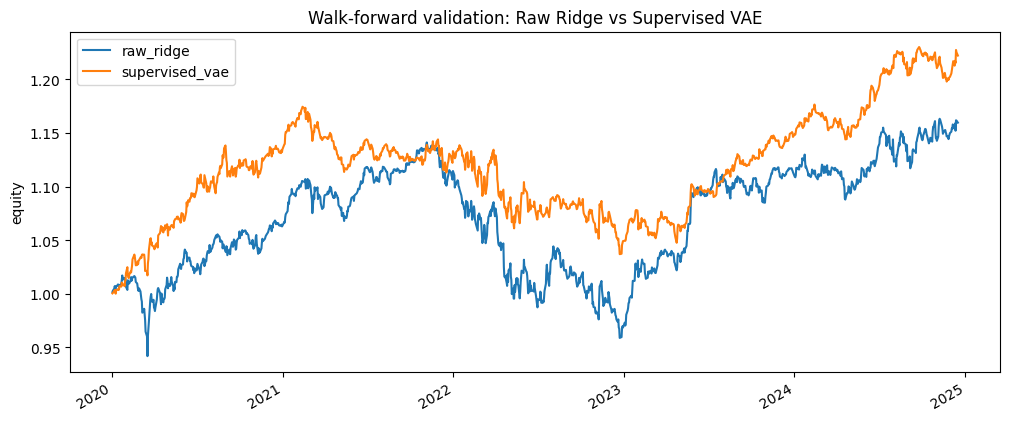

In [35]:
walk_forward_returns = pd.concat(all_returns).sort_index()

equity = (1 + walk_forward_returns[["raw_ridge", "supervised_vae"]]).cumprod()

equity.plot(
    figsize=(12, 5),
    title="Walk-forward validation: Raw Ridge vs Supervised VAE"
)

plt.ylabel("equity")
plt.show()

In [36]:
results_df.to_csv(
    DATA_BACKTESTS / "walk_forward_validation_results.csv",
    index=False
)

walk_forward_returns.to_parquet(
    DATA_BACKTESTS / "walk_forward_validation_returns.parquet"
)

In [37]:
results_df

,train_start,train_end,test_start,test_end,raw_sharpe,sup_vae_sharpe,raw_total_return,sup_vae_total_return,raw_max_drawdown,sup_vae_max_drawdown,raw_turnover,sup_vae_turnover,sup_best_val_corr,sup_best_epoch
0,2015-01-01,2019-12-31,2020-01-01,2020-12-31,0.957380,2.321453,0.063582,0.134876,-0.073951,-0.026277,0.026614,0.017128,0.090052,0
1,2016-01-01,2020-12-31,2021-01-01,2021-12-31,0.933880,-0.033029,0.047978,-0.001501,-0.035392,-0.052171,0.028307,0.028042,0.215866,1
2,2017-01-01,2021-12-31,2022-01-01,2022-12-31,-1.421151,-0.966250,-0.131020,-0.074112,-0.136634,-0.089253,0.016467,0.023108,0.120277,0
3,2018-01-01,2022-12-31,2023-01-01,2023-12-31,2.720257,2.205198,0.149488,0.092652,-0.028168,-0.028360,0.032800,0.037067,0.026991,9
4,2019-01-01,2023-12-31,2024-01-01,2024-12-31,0.724773,1.582618,0.041617,0.066179,-0.037128,-0.027631,0.019559,0.036088,0.106309,9


In [39]:
print(
    "Years VAE wins:",
    (results_df["sup_vae_sharpe"] > results_df["raw_sharpe"]).sum()
)

print("Total years:", len(results_df))

Years VAE wins: 3
Total years: 5
